<a href="https://colab.research.google.com/github/kamali1511/Portfolio-Optimization-Using-Modern-Portfolio-Theory-Using-Indian-Stocks/blob/main/Portfolio_Optimization_Using_Modern_Portfolio_Theory_(Indian_Stocks).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import the required packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
# -----------------------------
# STEP 1: Define Stocks
# -----------------------------
stocks = [
    "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS",
    "TCS.NS", "INFY.NS", "WIPRO.NS",
    "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS",
    "SUNPHARMA.NS", "DRREDDY.NS", "CIPLA.NS",
    "RELIANCE.NS", "NTPC.NS", "ADANIPORTS.NS"
]


In [3]:
TRADING_DAYS = 252
risk_free_rate = 0.05  # 5% (India approx)


In [5]:
# -----------------------------
# STEP 2: Download & Clean Data
# -----------------------------
data = yf.download(stocks, start="2020-01-01", end="2025-01-01")['Close']

print("\nMissing values before cleaning:\n", data.isnull().sum())

# Handle missing values
data = data.ffill()
data = data.bfill()

# Drop any remaining NaNs
data = data.dropna()

# Remove duplicate rows (if any)
data = data[~data.index.duplicated()]

print("\nMissing values after cleaning:\n", data.isnull().sum())

# Data validation
print("\nData Shape:", data.shape)
print("Date Range:", data.index.min(), "to", data.index.max())


/tmp/ipykernel_1530/4280749851.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2020-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  15 of 15 completed



Missing values before cleaning:
 Ticker
ADANIPORTS.NS    0
CIPLA.NS         0
DRREDDY.NS       0
HDFCBANK.NS      0
HINDUNILVR.NS    0
ICICIBANK.NS     0
INFY.NS          0
ITC.NS           0
NESTLEIND.NS     0
NTPC.NS          0
RELIANCE.NS      0
SBIN.NS          0
SUNPHARMA.NS     0
TCS.NS           0
WIPRO.NS         0
dtype: int64

Missing values after cleaning:
 Ticker
ADANIPORTS.NS    0
CIPLA.NS         0
DRREDDY.NS       0
HDFCBANK.NS      0
HINDUNILVR.NS    0
ICICIBANK.NS     0
INFY.NS          0
ITC.NS           0
NESTLEIND.NS     0
NTPC.NS          0
RELIANCE.NS      0
SBIN.NS          0
SUNPHARMA.NS     0
TCS.NS           0
WIPRO.NS         0
dtype: int64

Data Shape: (1238, 15)
Date Range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00


In [6]:
# -----------------------------
# STEP 3: Calculate Log Returns
# -----------------------------
returns = np.log(data / data.shift(1)).dropna()

In [7]:
# -----------------------------
# STEP 4: Remove Outliers (Optional)
# -----------------------------
z_scores = (returns - returns.mean()) / returns.std()
returns = returns[(np.abs(z_scores) < 3).all(axis=1)]


In [8]:
# -----------------------------
# STEP 5: Mean Returns & Covariance
# -----------------------------
mean_returns = returns.mean() * TRADING_DAYS
cov_matrix = returns.cov() * TRADING_DAYS


In [9]:
# -----------------------------
# STEP 6: Portfolio Simulation
# -----------------------------
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.sum(weights * mean_returns)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Avoid division error
    if portfolio_std_dev == 0:
        sharpe_ratio = 0
    else:
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std_dev

    results[0, i] = portfolio_return
    results[1, i] = portfolio_std_dev
    results[2, i] = sharpe_ratio


In [10]:
# -----------------------------
# STEP 7: Convert to DataFrame
# -----------------------------
results_df = pd.DataFrame(results.T, columns=['Return', 'Risk', 'Sharpe'])

# Add weights to dataframe
weights_df = pd.DataFrame(weights_record, columns=stocks)
results_df = pd.concat([results_df, weights_df], axis=1)


In [11]:
# -----------------------------
# STEP 8: Identify Optimal Portfolios
# -----------------------------
max_sharpe_idx = results_df['Sharpe'].idxmax()
min_vol_idx = results_df['Risk'].idxmin()

max_sharpe_portfolio = results_df.loc[max_sharpe_idx]
min_vol_portfolio = results_df.loc[min_vol_idx]


In [12]:
# -----------------------------
# STEP 9: Print Results
# -----------------------------
print("\nMaximum Sharpe Ratio Portfolio:\n", max_sharpe_portfolio)
print("\nMinimum Variance Portfolio:\n", min_vol_portfolio)



Maximum Sharpe Ratio Portfolio:
 Return           0.260559
Risk             0.137388
Sharpe           1.532585
HDFCBANK.NS      0.129593
ICICIBANK.NS     0.032591
SBIN.NS          0.016074
TCS.NS           0.003701
INFY.NS          0.014994
WIPRO.NS         0.080711
HINDUNILVR.NS    0.056924
ITC.NS           0.071861
NESTLEIND.NS     0.021118
SUNPHARMA.NS     0.129532
DRREDDY.NS       0.117816
CIPLA.NS         0.115807
RELIANCE.NS      0.117159
NTPC.NS          0.083131
ADANIPORTS.NS    0.008987
Name: 433, dtype: float64

Minimum Variance Portfolio:
 Return           0.148075
Risk             0.112661
Sharpe           0.870528
HDFCBANK.NS      0.022350
ICICIBANK.NS     0.083519
SBIN.NS          0.108754
TCS.NS           0.113129
INFY.NS          0.096153
WIPRO.NS         0.034099
HINDUNILVR.NS    0.003167
ITC.NS           0.111331
NESTLEIND.NS     0.120814
SUNPHARMA.NS     0.050412
DRREDDY.NS       0.036939
CIPLA.NS         0.025814
RELIANCE.NS      0.094267
NTPC.NS          0.058211


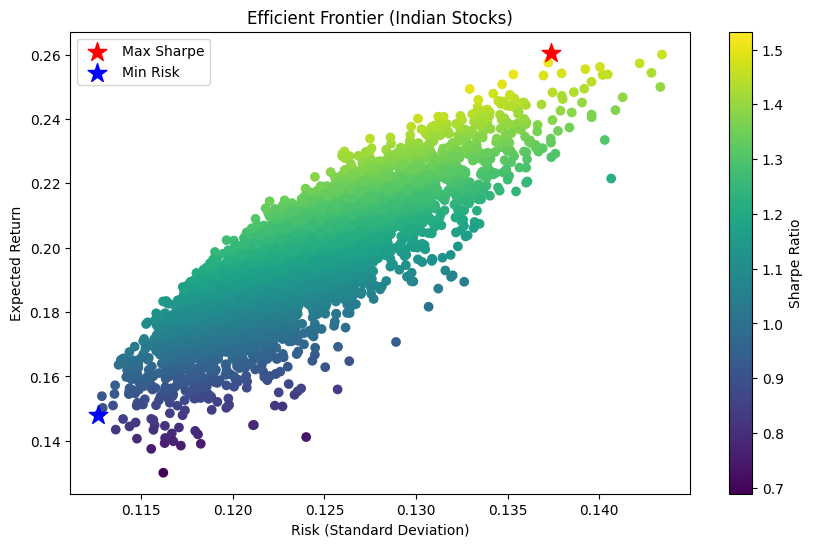

In [13]:
# -----------------------------
# STEP 10: Plot Efficient Frontier
# -----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis')

plt.colorbar(label='Sharpe Ratio')
plt.scatter(max_sharpe_portfolio['Risk'], max_sharpe_portfolio['Return'], color='red', marker='*', s=200, label='Max Sharpe')
plt.scatter(min_vol_portfolio['Risk'], min_vol_portfolio['Return'], color='blue', marker='*', s=200, label='Min Risk')

plt.title('Efficient Frontier (Indian Stocks)')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.legend()
plt.show()


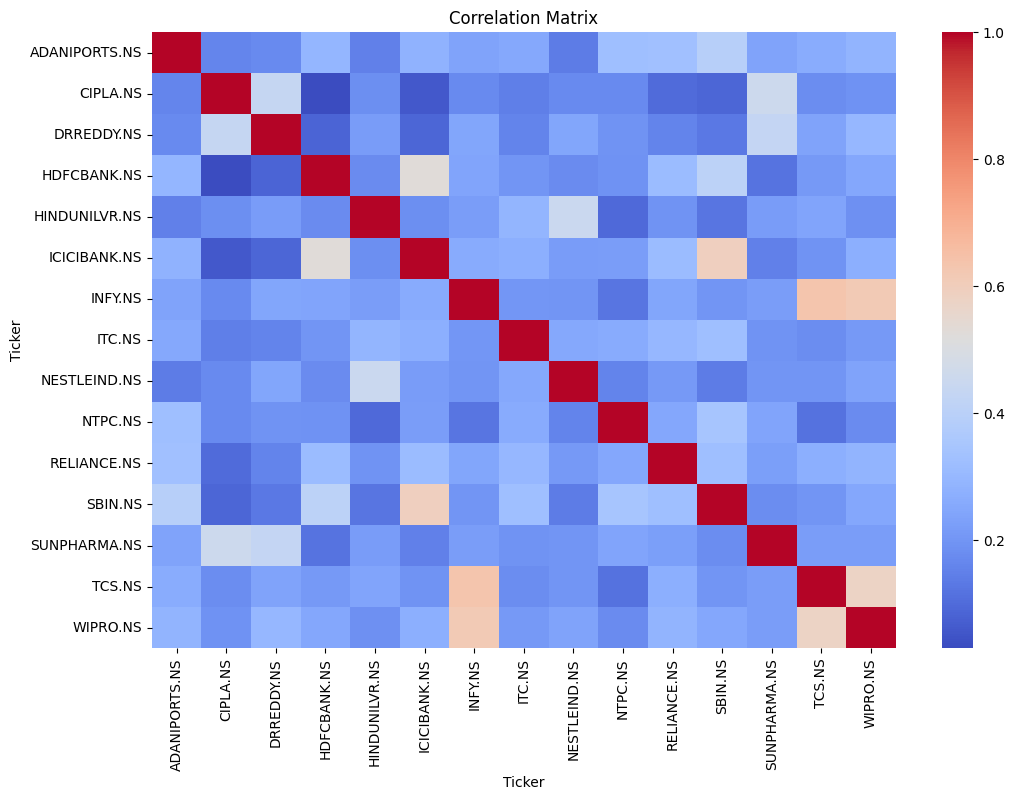

In [14]:
# -----------------------------
# STEP 11: Correlation Heatmap
# -----------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(returns.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [15]:
# -----------------------------
# STEP 12: Show Weights of Best Portfolio
# -----------------------------
print("\nWeights of Maximum Sharpe Portfolio:\n")
for stock in stocks:
    print(stock, ":", max_sharpe_portfolio[stock])



Weights of Maximum Sharpe Portfolio:

HDFCBANK.NS : 0.12959292669873115
ICICIBANK.NS : 0.032591247895088674
SBIN.NS : 0.0160737704947722
TCS.NS : 0.003701114109328261
INFY.NS : 0.014994234662978737
WIPRO.NS : 0.08071074357066033
HINDUNILVR.NS : 0.056924395813296565
ITC.NS : 0.07186079888485505
NESTLEIND.NS : 0.02111841376691767
SUNPHARMA.NS : 0.12953228763830235
DRREDDY.NS : 0.11781634746768299
CIPLA.NS : 0.11580688383239077
RELIANCE.NS : 0.11715923758686997
NTPC.NS : 0.08313094049338066
ADANIPORTS.NS : 0.008986657084744509
